# Métricas de Clasificación en ML: Accuracy, Precision, Recall, F1

**Objetivo:** Entender y aplicar correctamente las métricas de evaluación más usadas en clasificación, con fórmulas, un ejemplo numérico, notas para casos multiclase/desbalance y código en Python (scikit-learn) para un caso práctico.

**Contenido:**
- Matriz de confusión (binaria)
- Accuracy (Exactitud)
- Precision (PPV)
- Recall (Sensibilidad, TPR)
- F1-Score
- Ejemplo numérico paso a paso
- Código de referencia con `scikit-learn` (binario y multiclase)
- Elección de la métrica según el contexto


## 0) Matriz de confusión (binaria)

La matriz de confusión es una tabla que te permite visualizar el rendimiento de un algoritmo de clasificación, especialmente en problemas de clasificación binaria. Muestra el número de predicciones correctas e incorrectas para cada clase, desglosándolas en Verdaderos Positivos (TP), Falsos Positivos (FP), Falsos Negativos (FN) y Verdaderos Negativos (TN).

En resumen, te ayuda a entender:

- Cuántas veces el modelo predijo correctamente la clase positiva (TP).
- Cuántas veces el modelo predijo la clase negativa correctamente (TN).

- Cuántas veces el modelo se equivocó al predecir un negativo como positivo (FP - Error Tipo I).

- Cuántas veces el modelo se equivocó al predecir un positivo como negativo (FN - Error Tipo II).

A partir de esta matriz, se calculan métricas como Accuracy, Precision, Recall y F1-Score, que proporcionan una visión más completa del desempeño del modelo que solo la Accuracy.

Asumimos **clase positiva = 1**.

- **TP (True Positive):** positivos bien predichos.
- **FP (False Positive):** negativos predichos como positivos.
- **FN (False Negative):** positivos que el modelo no detectó.
- **TN (True Negative):** negativos bien predichos.

El total de muestras es:  
$$ N = TP + FP + FN + TN $$


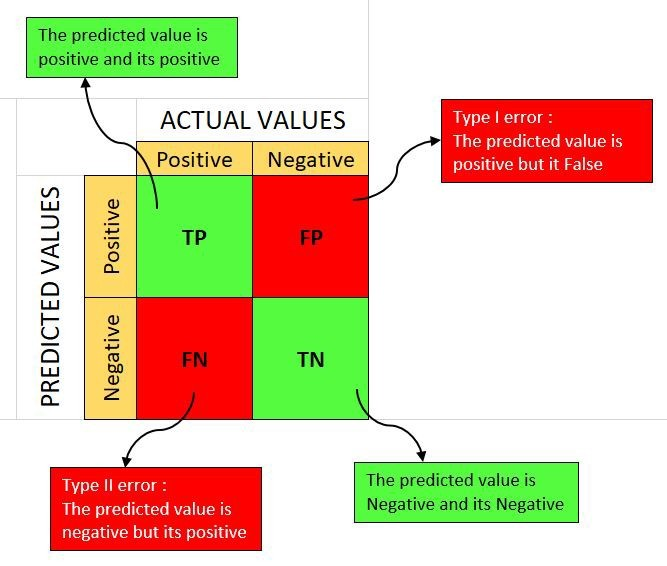

In [ ]:
import numpy as np

# Ejemplo numérico binario con TP, FP, FN, TN
TP, FP, FN, TN = 90, 10, 30, 870

# Crear la matriz de confusión con los valores dados
confusion_matrix_example = np.array([[TN, FP], [FN, TP]])

print("Matriz de confusión:")
print(confusion_matrix_example)

## 1) Accuracy (Exactitud)
Proporción de aciertos totales.

$$ \text{Accuracy} = \frac{TP + TN}{N} $$

**Útil:** clases balanceadas y costos de error similares.  
**Cuidado:** puede ser engañosa con clases muy desbalanceadas (p. ej., enfermedad rara).

## 2) Precision (Precisión, PPV)
De lo que el modelo marcó como positivo, ¿cuánto realmente lo es?

$$ \text{Precision} = \frac{TP}{TP + FP} $$

**Útil:** cuando **FP** son costosos (p. ej., activar una alerta cara o contactar a un cliente por error).

## 3) Recall (Sensibilidad, TPR)
De todos los positivos reales, ¿cuántos detectó?

$$ \text{Recall} = \frac{TP}{TP + FN} $$

**Útil:** cuando **FN** son costosos (p. ej., no detectar fraude, fallas o pacientes enfermos).

## 4) F1-Score
La **media armónica** entre *precision* y *recall* (penaliza más los valores extremos):

$$ F1 = 2\cdot \frac{\text{Precision}\cdot\text{Recall}}{\text{Precision}+\text{Recall}} $$



Donde $P=\text{Precision}$ y $R=\text{Recall}$.  
**Útil:** un resumen único cuando hay desbalance y necesitas equilibrio entre *Precision/Recall*.

## Ejemplo numérico (binario)
Supón: $TP=90,\ FP=10,\ FN=30,\ TN=870 \Rightarrow N=1000$.

**Cálculos:**
- $\text{Accuracy}=\frac{90+870}{1000}=0.96$  
- $\text{Precision}=\frac{90}{90+10}=0.90$  
- $\text{Recall}=\frac{90}{90+30}=\frac{90}{120}=0.75$  
- $F1 = 2\cdot \frac{0.90\cdot 0.75}{0.90+0.75} \approx 0.818$

**Observación:** 96% de *accuracy* parece “excelente”, pero el *recall* (0.75) indica que falla 25% de los positivos. Si **FN** fueran críticos, este modelo no es suficiente.

In [ ]:
# Ejemplo numérico binario con TP, FP, FN, TN
TP, FP, FN, TN = 90, 10, 30, 870
N = TP + FP + FN + TN

accuracy = (TP + TN) / N
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

print(f"N = {N}")
print(f"Accuracy = {accuracy:.3f}")
print(f"Precision = {precision:.3f}")
print(f"Recall = {recall:.3f}")
print(f"F1 = {f1:.3f}")

## Umbral de decisión y *trade-offs*
Los clasificadores probabilísticos (p. ej., regresión logística, XGBoost) devuelven *scores/probabilidades*.  
Cambiar el **umbral** (por defecto 0.5) ajusta *Precision* vs *Recall*.  
Selecciona el umbral según el **costo** de FP/FN o maximizando una métrica (p. ej., F1).

## Código de referencia (scikit-learn) — Caso binario
Entrenamos una **Regresión Logística** sobre `breast_cancer` y reportamos métricas, matriz de confusión, y curvas ROC y Precision-Recall.

In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    precision_recall_curve, roc_curve, average_precision_score
)

# Datos binarios
X, y = load_breast_cancer(return_X_y=True, as_frame=False)
# Clase positiva explícita: 1 = maligno; 0 = benigno.
y = (y == 0).astype(int)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Preprocesamiento
scaler = StandardScaler().fit(X_tr)
X_tr = scaler.transform(X_tr)
X_te = scaler.transform(X_te)

# Modelo y predicciones
clf = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
y_pred = clf.predict(X_te)
y_score = clf.predict_proba(X_te)[:, 1]   # scores para ROC/PR

# Métricas básicas
print("Accuracy :", accuracy_score(y_te, y_pred))
print("Precision:", precision_score(y_te, y_pred))
print("Recall   :", recall_score(y_te, y_pred))
print("F1       :", f1_score(y_te, y_pred))


# Reporte y matriz de confusión
print("\nMatriz de confusión:\n", confusion_matrix(y_te, y_pred))
print("\nReporte por clase:\n", classification_report(y_te, y_pred, target_names=["benigno", "maligno"]))

import matplotlib.pyplot as plt
fpr, tpr, _ = roc_curve(y_te, y_score)
precision, recall, _ = precision_recall_curve(y_te, y_score)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_te, y_score):.3f}")
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set(xlabel='Tasa de falsos positivos', ylabel='Sensibilidad', title='ROC')
axes[1].plot(recall, precision, label=f"AP = {average_precision_score(y_te, y_score):.3f}")
axes[1].axhline(y_te.mean(), linestyle='--', color='gray', label='Prevalencia')
axes[1].set(xlabel='Sensibilidad', ylabel='Precisión', title='Precision-Recall')
for ax in axes: ax.legend()
plt.tight_layout()
plt.show()


## ¿Qué métrica escoger?
- **Accuracy:** clases balanceadas y costos similares.
- **Precision alta:** evitar FP (p. ej., marcar fraude/alarma solo si estás muy seguro).
- **Recall alto:** evitar FN (p. ej., tamizaje médico donde no quieres perder casos).
- **F1:** un número único cuando necesitas equilibrio y hay desbalance.